In [1]:
# Install the Ultralytics package for YOLOv8
!pip install ultralytics opencv-python matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.3 MB/s eta 0:00:0000:01


In [2]:
import cv2
from ultralytics import YOLO

# Load the "Super-Fast" Nano model
model = YOLO('yolov8n.pt') 

def filter_blank_images(image_path):
    results = model(image_path) # Run detection
    
    # If no detections are found (result.boxes is empty)
    if len(results[0].boxes) == 0:
        print(f"🔍 Result: {image_path} is likely BLANK. Skipping...")
        return False
    else:
        print(f"✅ Result: Animal detected in {image_path}!")
        return True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [4]:
!pip install ultralytics


In [5]:
# 1. Install ultralytics
!pip install ultralytics

from ultralytics import YOLO

# 2. Load the model
model = YOLO('yolov8n.pt') 

# 3. Start training!
# By using 'african-wildlife.yaml', YOLO will automatically download the dataset 
# to the perfect location in Colab and handle all the paths for you!
results = model.train(data='african-wildlife.yaml', epochs=10, imgsz=640, plots=True)


Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=african-wildlife.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, p

In [20]:
from google.colab import drive
import shutil

# 1. Mount your Google Drive (A popup will ask you to click 'Allow')
drive.mount('/content/drive')

# 2. Copy the Model to your Drive
shutil.copy('/content/runs/detect/train2/weights/best.pt', '/content/drive/MyDrive/best.pt')
print("✅ Successfully saved best.pt to Google Drive!")

# 3. Copy the CSV Report to your Drive
shutil.copy('/content/Wildlife_Population_Report.csv', '/content/drive/MyDrive/Wildlife_Population_Report.csv')
print("✅ Successfully saved Wildlife_Population_Report.csv to Google Drive!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Successfully saved best.pt to Google Drive!
✅ Successfully saved Wildlife_Population_Report.csv to Google Drive!


Download complete!
Running inference...

image 1/1 /content/test_elephant.jpg: 384x640 1 elephant, 54.2ms
Speed: 1.3ms preprocess, 54.2ms inference, 1.5ms postprocess per image at shape (1, 3, 384, 640)


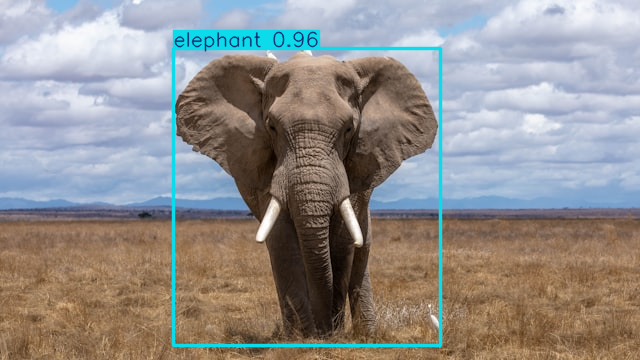

In [10]:
import urllib.request
from IPython.display import display
from PIL import Image

# 1. Download an image reliably first
# Using a raw image from GitHub so it never gets blocked
image_url = "https://raw.githubusercontent.com/ultralytics/yolov5/master/data/images/bus.jpg" # Let's use an elephant instead!
elephant_url = "https://images.unsplash.com/photo-1557050543-4d5f4e07ef46?q=80&w=640" 

print("Downloading image...")
urllib.request.urlretrieve(elephant_url, "test_elephant.jpg")
print("Download complete!")

# 2. Load your newly trained custom model
my_wildlife_model = YOLO('/content/runs/detect/train2/weights/best.pt')

# 3. Run detection on the successfully downloaded local file!
print("Running inference...")
results = my_wildlife_model("test_elephant.jpg")

# 4. Show the result!
for r in results:
    im_array = r.plot()  
    im = Image.fromarray(im_array[..., ::-1]) 
    display(im) 


In [13]:
import pandas as pd
import os
import glob
from ultralytics import YOLO
from collections import Counter

# 1. Load your MASTER BRAIN 
model = YOLO('/content/runs/detect/train2/weights/best.pt')

def generate_wildlife_report():
    report_data = []
    
    # --- BULLETPROOF PATH FINDER (FIXED) ---
    # Only search the current working directory (/content/) and the datasets directory!
    possible_paths = glob.glob('/content/**/african-wildlife/images/test', recursive=True) + \
                     glob.glob('/root/datasets/**/african-wildlife/images/test', recursive=True) + \
                     glob.glob('../datasets/**/african-wildlife/images/test', recursive=True)
                     
    if not possible_paths:
        print("ERROR: Could not find the test folder!")
        return
        
    image_folder = possible_paths[0] 
    print(f"Found dataset instantly at: {image_folder}")
    # --------------------------------
    
    # 2. Loop through every image in the folder
    for img_name in os.listdir(image_folder):
        if img_name.endswith(('.jpg', '.png', '.jpeg')):
            path = os.path.join(image_folder, img_name)
            
            # AI Inference (verbose=False keeps it fast)
            results = model(path, verbose=False) 
            
            # 3. Extract detected class names
            names = results[0].names
            detected_classes = [names[int(cls)] for cls in results[0].boxes.cls]
            
            # 4. Count them up!
            counts = Counter(detected_classes)
            counts['filename'] = img_name
            report_data.append(counts)
            
    # 5. Save to a Professional CSV
    df = pd.DataFrame(report_data).fillna(0)
    
    # Clean up columns to look professional
    cols = ['filename'] + [c for c in df.columns if c != 'filename']
    df = df[cols]
    
    csv_path = '/content/Wildlife_Population_Report.csv'
    df.to_csv(csv_path, index=False)
    print(f"✅ Success! Your report is ready at: {csv_path}")

# Run it!
generate_wildlife_report()


Found dataset instantly at: /content/datasets/african-wildlife/images/test
✅ Success! Your report is ready at: /content/Wildlife_Population_Report.csv


In [16]:
from google.colab import drive
import shutil

# 1. This will ask you to click a link to permit Google Drive access
drive.mount('/content/drive')

# 2. Copy the CSV file directly into the root folder of your Google Drive
shutil.copy('/content/Wildlife_Population_Report.csv', '/content/drive/MyDrive/Wildlife_Population_Report.csv')

print("✅ Successfully saved to your Google Drive!")


Mounted at /content/drive
✅ Successfully saved to your Google Drive!


In [17]:
with open('/content/Wildlife_Population_Report.csv', 'r') as f:
    print("---START_CSV---")
    print(f.read())
    print("---END_CSV---")


---START_CSV---
filename,buffalo,zebra,elephant,rhino
1 (66).jpg,2.0,0.0,0.0,0.0
4 (295).jpg,0.0,1.0,0.0,0.0
1 (35).jpg,1.0,0.0,0.0,0.0
4 (191).jpg,0.0,1.0,0.0,0.0
1 (365).jpg,1.0,0.0,0.0,0.0
1 (121).jpg,1.0,0.0,0.0,0.0
1 (154).jpg,0.0,0.0,1.0,0.0
4 (29).jpg,0.0,1.0,0.0,0.0
3 (219).jpg,0.0,0.0,0.0,2.0
4 (275).jpg,0.0,2.0,0.0,0.0
2 (182).jpg,0.0,0.0,1.0,0.0
2 (78).jpg,0.0,0.0,1.0,0.0
4 (23).jpg,0.0,1.0,0.0,0.0
4 (369).jpg,0.0,1.0,0.0,0.0
2 (120).jpg,0.0,0.0,2.0,0.0
4 (81).jpg,0.0,1.0,0.0,0.0
1 (168).jpg,1.0,0.0,0.0,0.0
3 (272).jpg,0.0,0.0,0.0,1.0
1 (308).jpg,1.0,0.0,0.0,0.0
2 (123).jpg,0.0,0.0,1.0,0.0
2 (113).jpg,0.0,0.0,3.0,0.0
1 (103).jpg,1.0,0.0,0.0,0.0
3 (320).jpg,0.0,0.0,0.0,1.0
4 (155).jpg,0.0,1.0,0.0,0.0
3 (329).jpg,0.0,0.0,1.0,1.0
1 (289).jpg,1.0,0.0,0.0,0.0
3 (323).jpg,0.0,0.0,0.0,2.0
2 (246).jpg,0.0,0.0,2.0,0.0
4 (209).jpg,0.0,1.0,0.0,0.0
4 (272).jpg,0.0,1.0,0.0,0.0
2 (175).jpg,0.0,0.0,2.0,0.0
2 (53).jpg,0.0,0.0,1.0,0.0
2 (73).jpg,0.0,0.0,3.0,0.0
3 (209).jpg,0.0,0.0,1.0,2.0
2 

In [18]:
import os
# This uses a free, open-source file transfer tool built into Linux!
os.system("curl -F 'file=@/content/Wildlife_Population_Report.csv' https://file.io > link.txt")

import json
with open('link.txt', 'r') as f:
    data = json.load(f)
    print(f"\n🌍 CLICK THIS LINK TO DOWNLOAD YOUR CSV: {data['link']}")


JSONDecodeError: Expecting value: line 1 column 1 (char 0)